# Analiza turizma v Mariboru v obdobju 2020–2025

V projektni nalogi analiziram mesečne podatke o turističnih prihodih in prenočitvah v Mestni občini Maribor. Podatki so pridobljeni iz uradne baze SiStat Statističnega urada Republike Slovenije.

Za temo sem se odločila, ker me zanima turizem v Mariboru in predvsem, ali ima mesto izrazito turistično sezono, od kod prihajajo obiskovalci in kako se je turizem spreminjal po letu 2020.

Glavna vprašanja so:

1. Kako se je spreminjalo število prihodov in prenočitev?
2. Kateri meseci so najbolj obiskani?
3. Iz katerih držav prihaja največ turistov?
4. Kako dolgo turisti povprečno ostanejo?
5. Ali lahko pri izrazitejših odstopanjih poiščemo smiselne možne razlage v dogajanju in turistični ponudbi mesta?


## 1. Uvoz podatkov

Program `zajem_podatkov.py` podatke pridobi iz spletne baze SiStat in jih shrani v datoteko `podatki/turizem_maribor.csv`.

V analizi uporabljam predvsem knjižnico Pandas, ki smo jo obravnavali pri predmetu.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

podatki = pd.read_csv("podatki/turizem_maribor.csv")
podatki.head(10)

,mesec,obcina,drzava,meritev,vrednost
0,2020M01,Maribor,0 Država - SKUPAJ,Prihodi turistov,11453.0
1,2020M01,Maribor,0 Država - SKUPAJ,Prenočitve turistov,30507.0
2,2020M01,Maribor,1 DOMAČI,Prihodi turistov,2014.0
3,2020M01,Maribor,1 DOMAČI,Prenočitve turistov,3884.0
4,2020M01,Maribor,2 TUJI,Prihodi turistov,9439.0
5,2020M01,Maribor,2 TUJI,Prenočitve turistov,26623.0
6,2020M01,Maribor,2.1 Avstrija,Prihodi turistov,601.0
7,2020M01,Maribor,2.1 Avstrija,Prenočitve turistov,945.0
8,2020M01,Maribor,2.2 Belgija,Prihodi turistov,42.0
9,2020M01,Maribor,2.2 Belgija,Prenočitve turistov,94.0


Najprej pogledam osnovne informacije o tabeli in preverim, ali so se podatki pravilno naložili.

In [2]:
len(podatki)

8064

In [3]:
podatki.columns

Index(['mesec', 'obcina', 'drzava', 'meritev', 'vrednost'], dtype='str')

In [4]:
podatki.meritev.unique()

<StringArray>
['Prihodi turistov', 'Prenočitve turistov']
Length: 2, dtype: str

V podatkih se pri državah pojavijo tudi skupne kategorije, kot so vse države skupaj, domači turisti in tuji turisti. Za različne dele analize zato uporabljam različne podmnožice podatkov.

In [5]:
podatki["leto"] = podatki.mesec.str[:4].astype(int)
podatki["stevilka_meseca"] = podatki.mesec.str[-2:].astype(int)

podatki.head()

,mesec,obcina,drzava,meritev,vrednost,leto,stevilka_meseca
0,2020M01,Maribor,0 Država - SKUPAJ,Prihodi turistov,11453.0,2020,1
1,2020M01,Maribor,0 Država - SKUPAJ,Prenočitve turistov,30507.0,2020,1
2,2020M01,Maribor,1 DOMAČI,Prihodi turistov,2014.0,2020,1
3,2020M01,Maribor,1 DOMAČI,Prenočitve turistov,3884.0,2020,1
4,2020M01,Maribor,2 TUJI,Prihodi turistov,9439.0,2020,1


## 2. Razvoj turizma skozi leta

Najprej uporabim kategorijo vseh držav skupaj. Tako posameznih držav ne seštevam, saj bi lahko zaradi skupnih kategorij prišlo do dvojnega štetja.


In [6]:
skupaj = podatki[podatki.drzava.str.contains("SKUPAJ|TOTAL", case=False, na=False)]
skupaj.head()

,mesec,obcina,drzava,meritev,vrednost,leto,stevilka_meseca
0,2020M01,Maribor,0 Država - SKUPAJ,Prihodi turistov,11453.0,2020,1
1,2020M01,Maribor,0 Država - SKUPAJ,Prenočitve turistov,30507.0,2020,1
112,2020M02,Maribor,0 Država - SKUPAJ,Prihodi turistov,10614.0,2020,2
113,2020M02,Maribor,0 Država - SKUPAJ,Prenočitve turistov,29199.0,2020,2
224,2020M03,Maribor,0 Država - SKUPAJ,Prihodi turistov,3192.0,2020,3


Če SURS ime skupne kategorije prikaže nekoliko drugače in je zgornja tabela prazna, lahko pogledamo vse kategorije držav ter izberemo prvo skupno kategorijo.

In [7]:
podatki.drzava.unique()[:10]

<StringArray>
[       '0 Država - SKUPAJ',                 '1 DOMAČI',
                   '2 TUJI',             '2.1 Avstrija',
              '2.2 Belgija',            '2.3 Bolgarija',
 '2.4 Bosna in Hercegovina',                '2.5 Ciper',
      '2.6 Češka republika',            '2.7 Črna gora']
Length: 10, dtype: str

In [8]:
prihodi = skupaj[skupaj.meritev.str.contains("prihod", case=False, na=False)]
prenocitve = skupaj[skupaj.meritev.str.contains("preno", case=False, na=False)]

prihodi_po_letih = prihodi.groupby("leto").vrednost.sum()
prenocitve_po_letih = prenocitve.groupby("leto").vrednost.sum()

prihodi_po_letih

leto
2020     72380.0
2021    103353.0
2022    195742.0
2023    239177.0
2024    253481.0
2025    270729.0
Name: vrednost, dtype: float64

In [9]:
prenocitve_po_letih

leto
2020    196397.0
2021    247334.0
2022    432467.0
2023    531614.0
2024    511937.0
2025    537564.0
Name: vrednost, dtype: float64

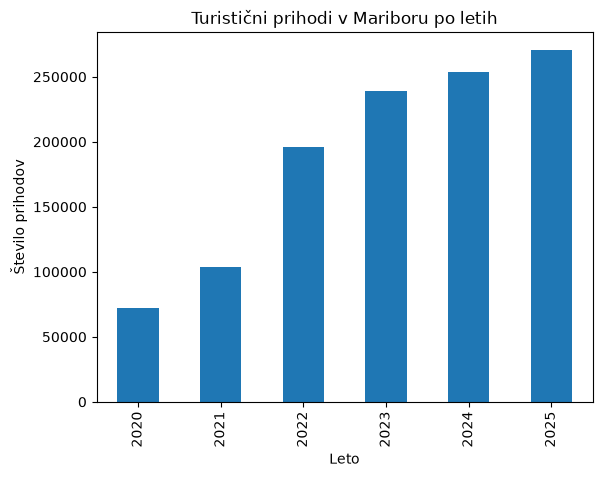

In [10]:
prihodi_po_letih.plot(
    kind="bar",
    title="Turistični prihodi v Mariboru po letih",
    xlabel="Leto",
    ylabel="Število prihodov"
)
plt.show()

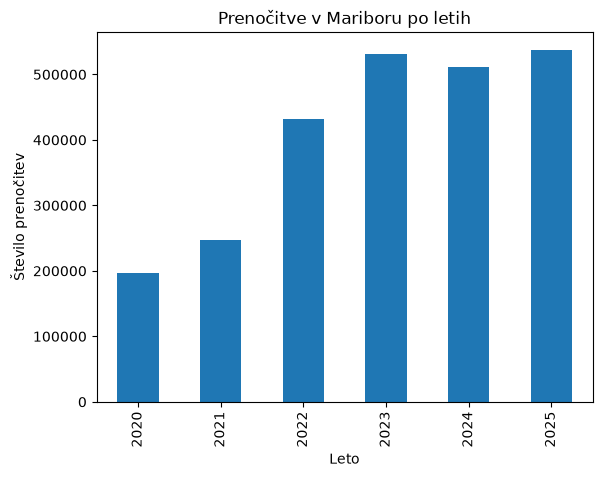

In [11]:
prenocitve_po_letih.plot(
    kind="bar",
    title="Prenočitve v Mariboru po letih",
    xlabel="Leto",
    ylabel="Število prenočitev"
)
plt.show()

### Interpretacija

Pri rezultatih je opazna hitra rast turističnega obiska po letu 2020. Število prihodov se je povečevalo v vseh opazovanih letih in je leta 2025 doseglo 270.729 prihodov. Pri prenočitvah je razvoj nekoliko drugačen. Leta 2023 je bilo zabeleženih 531.614 prenočitev, leta 2024 pa 511.937, kar pomeni manjši upad kljub večjemu številu prihodov. Leta 2025 se je število prenočitev ponovno povečalo in doseglo 537.564.

Leto 2020 zaradi epidemije covida-19 in omejitev potovanj ni običajno turistično leto, zato je pri primerjavi z naslednjimi leti treba to upoštevati. Posebej zanimiva je tudi razlika med letoma 2023 in 2024. Čeprav je bilo leta 2024 več turističnih prihodov, je bilo prenočitev manj. To lahko pomeni, da so obiskovalci v povprečju ostajali krajši čas. To bom preverila v nadaljevanju analize z izračunom povprečnega števila prenočitev na prihod.


## 3. Sezonskost turizma

Naslednje vprašanje je, v katerih mesecih je Maribor najbolj obiskan. Za vsak koledarski mesec izračunam povprečno število prenočitev v obdobju 2020–2025.


In [13]:
prenocitve_po_mesecih = prenocitve.groupby("stevilka_meseca").vrednost.mean()
prenocitve_po_mesecih

stevilka_meseca
1     27023.166667
2     26685.000000
3     22052.166667
4     24527.166667
5     32445.000000
6     38975.000000
7     52996.333333
8     53076.833333
9     37892.166667
10    37406.000000
11    27125.333333
12    29348.000000
Name: vrednost, dtype: float64

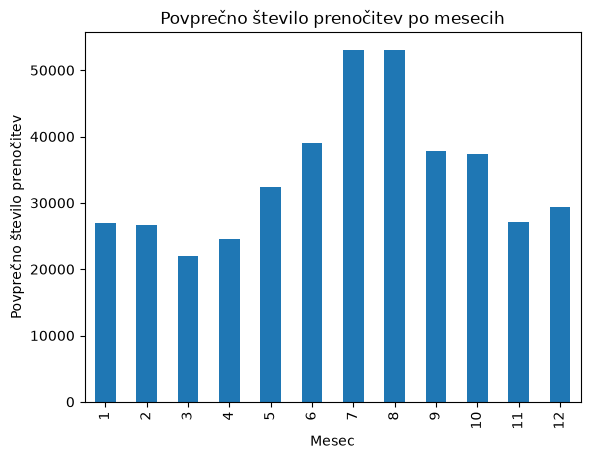

In [14]:
prenocitve_po_mesecih.plot(
    kind="bar",
    title="Povprečno število prenočitev po mesecih",
    xlabel="Mesec",
    ylabel="Povprečno število prenočitev"
)
plt.show()

### Interpretacija sezonskosti

Iz podatkov je razvidna precej izrazita sezonskost turizma v Mariboru. Največ prenočitev je v poletnih mesecih, predvsem julija in avgusta, ko je povprečno zabeleženih približno 53.000 prenočitev na mesec. Število prenočitev začne izraziteje naraščati maja in ostane razmeroma visoko tudi septembra in oktobra. Najmanj prenočitev je v povprečju marca.

Poletni vrh lahko povežemo z različnimi oblikami turistične ponudbe Maribora. Poleg mestnega turizma so pomembne aktivnosti na prostem, Pohorje pa v toplejšem delu leta ponuja pohodništvo in kolesarjenje ter Bike Park. Maribor ima tudi ponudbo, povezano z vinom, kulinariko in dogodki.

Zanimivo je, da obisk pozimi ni tako visok kot poleti, čeprav Pohorje omogoča tudi smučanje. Iz podatkov zato sklepam, da ima Maribor turistični obisk skozi vse leto, vendar je glavni vrh v poletnih mesecih. Iz samega grafa pa ne morem dokazati, katere dejavnosti so neposreden vzrok za večje število prenočitev.

## 4. Iz katerih držav prihajajo turisti?

Pri analizi držav izločim skupne kategorije in domače turiste. Zanimajo me posamezne tuje države.


In [17]:
posamezne_drzave = podatki[
    ~podatki.drzava.str.contains(
        "SKUPAJ|TOTAL|DOMAČ|DOMESTIC|TUJ|FOREIGN",
        case=False,
        na=False
    )
]

prenocitve_drzave = posamezne_drzave[
    posamezne_drzave.meritev.str.contains("preno", case=False, na=False)
]
prenocitve_drzave = prenocitve_drzave.copy()

prenocitve_drzave["drzava"] = prenocitve_drzave["drzava"].str.split(" ", n=1).str[1]
top_drzave = (
    prenocitve_drzave.groupby("drzava")
    .vrednost.sum()
    .sort_values(ascending=False)
    .head(10)
)

top_drzave

drzava
Nemčija                 249250.0
Hrvaška                 151290.0
Srbija                  135278.0
Poljska                 126319.0
Avstrija                124764.0
Italija                 113035.0
Češka republika          96358.0
Madžarska                94036.0
Bosna in Hercegovina     82437.0
Romunija                 81921.0
Name: vrednost, dtype: float64

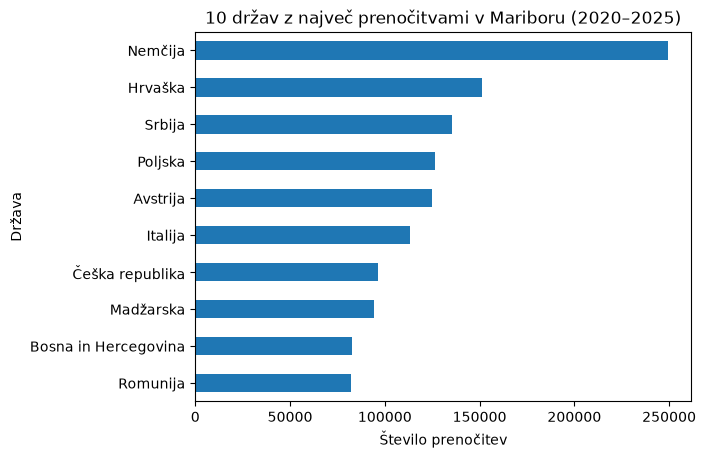

In [21]:
top_drzave.sort_values().plot(
    kind="barh",
    title="10 držav z največ prenočitvami v Mariboru (2020–2025)",
    xlabel="Število prenočitev",
    ylabel="Država"
)
plt.show()

### Interpretacija

V obdobju 2020–2025 so med tujimi turisti največ prenočitev v Mariboru ustvarili obiskovalci iz Nemčije. Sledijo Hrvaška, Srbija, Poljska in Avstrija. Nemčija precej izstopa, saj je bilo v opazovanem obdobju zabeleženih skoraj 250.000 prenočitev nemških turistov.

Med desetimi državami z največ prenočitvami prevladujejo evropske države. Med njimi je tudi več držav, ki so Sloveniji geografsko razmeroma blizu, na primer Hrvaška, Avstrija, Italija in Madžarska. Iz podatkov lahko ugotovim, iz katerih držav prihaja največ turistov, ne morem pa samo na podlagi teh podatkov ugotoviti razlogov za njihov obisk.


## 5. Povprečna dolžina bivanja

Povprečno dolžino bivanja približno izračunam kot razmerje med številom prenočitev in številom prihodov.

Če je na primer 20.000 prihodov in 40.000 prenočitev, to pomeni približno dve prenočitvi na en prihod.


In [18]:
dolzina_bivanja = prenocitve_po_letih / prihodi_po_letih
dolzina_bivanja

leto
2020    2.713415
2021    2.393099
2022    2.209373
2023    2.222680
2024    2.019627
2025    1.985617
Name: vrednost, dtype: float64

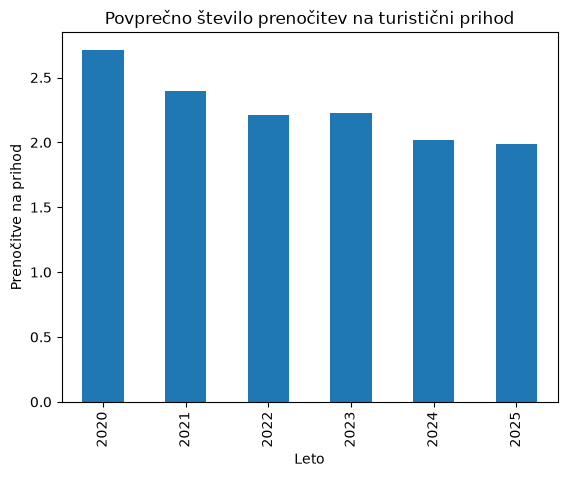

In [20]:
dolzina_bivanja.plot(
    kind="bar",
    title="Povprečno število prenočitev na turistični prihod",
    xlabel="Leto",
    ylabel="Prenočitve na prihod"
)
plt.show()

Povprečna dolžina bivanja se je v opazovanem obdobju večinoma zmanjševala. Leta 2020 je znašala približno 2,71 prenočitve na prihod, leta 2024 približno 2,02, leta 2025 pa nekoliko manj kot 2. To potrjuje prejšnjo ugotovitev, da večje število prihodov ne pomeni nujno tudi sorazmerno večjega števila prenočitev. Leta 2024 je bilo na primer prihodov več kot leta 2023, vendar je bila povprečna dolžina bivanja krajša.

Vrednost ni enaka natančnemu številu dni vsakega posameznega gosta, ampak je uporabno skupno razmerje med prenočitvami in prihodi.


## 6. Poseben primer: julij 2023 in OFEM

Zavod za turizem Maribor pri primerjavi let 2023 in 2024 posebej omenja, da je mesto leta 2023 gostilo športni festival OFEM. Zato pogledam mesečne prenočitve leta 2023 in preverim, ali julij izstopa.


In [22]:
prenocitve_2023 = prenocitve[prenocitve.leto == 2023]
prenocitve_2023[["mesec", "vrednost"]]

,mesec,vrednost
4033,2023M01,35628.0
4145,2023M02,36520.0
4257,2023M03,28646.0
4369,2023M04,35036.0
4481,2023M05,42877.0
4593,2023M06,53160.0
4705,2023M07,90514.0
4817,2023M08,59911.0
4929,2023M09,43137.0
5041,2023M10,41810.0


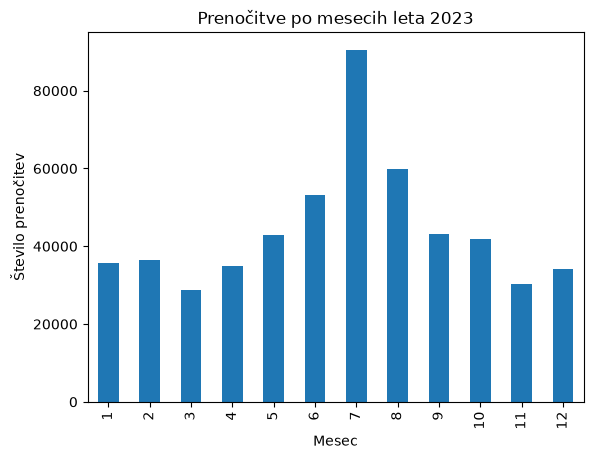

In [23]:
prenocitve_2023.plot(
    x="stevilka_meseca",
    y="vrednost",
    kind="bar",
    title="Prenočitve po mesecih leta 2023",
    xlabel="Mesec",
    ylabel="Število prenočitev",
    legend=False
)
plt.show()

Julij 2023 izrazito izstopa od drugih mesecev. Zabeleženih je bilo 90.514 prenočitev, medtem ko jih je bilo junija 53.160 in avgusta 59.911. Eden od možnih razlogov za tako velik julijski vrh je OFEM, ki ga kot posebnost leta 2023 omenja tudi Zavod za turizem Maribor. Iz samih podatkov pa ne morem dokazati, da je celotno povečanje povzročil samo ta dogodek.


## 7. Prenova Lenta kot možen dejavnik prihodnjega razvoja

Mestna občina Maribor navaja, da je prenova nabrežja Drave – Lent trajala od aprila 2022 do avgusta 2024. Namen prenove je bil med drugim narediti območje privlačnejše za prebivalce in obiskovalce.

Ker imam podatke samo do leta 2025, je obdobje po dokončanju prenove zelo kratko. Zato iz podatkov ne morem trditi, da je prenova povzročila spremembo turističnega obiska. Lahko pa pogledam, kako se leto 2025 primerja z letom 2024.


In [24]:
primerjava_lent = prenocitve_po_letih.loc[[2024, 2025]]
primerjava_lent

leto
2024    511937.0
2025    537564.0
Name: vrednost, dtype: float64

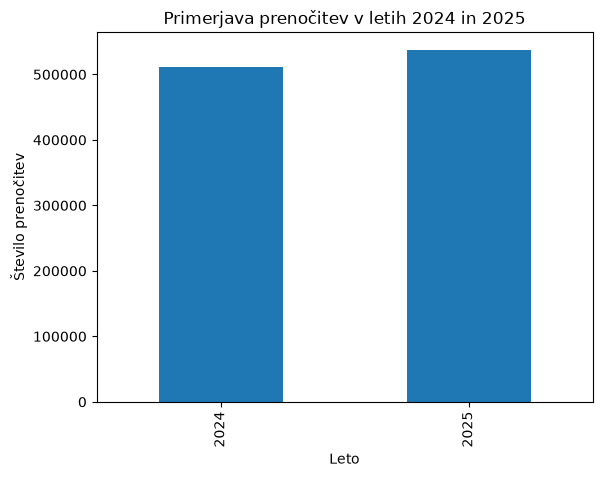

In [25]:
primerjava_lent.plot(
    kind="bar",
    title="Primerjava prenočitev v letih 2024 in 2025",
    xlabel="Leto",
    ylabel="Število prenočitev"
)
plt.show()

Tudi če je v letu 2025 opazna rast, tega ne morem neposredno pripisati prenovi Lenta. Na turizem vplivajo še dogodki, vreme, prometne povezave, gospodarske razmere, promocija destinacije in drugi dejavniki.


## 8. Zaključek

V nalogi sem s pomočjo podatkov SURS analizirala turizem v Mariboru med letoma 2020 in 2025. Zajem podatkov je avtomatiziran, podatki se shranijo v lokalni JSON in CSV datoteki, analiza pa je izvedena v Jupyter Notebooku.

Najpomembnejše ugotovitve po izvedbi analize povzamem tako:

- turizem se po posebnem letu 2020 postopoma spreminja in okreva;
- obisk Maribora se skozi leto razlikuje, pri čemer lahko sezonski vzorec delno povezujemo z raznovrstno ponudbo mesta in Pohorja;
- velik del prenočitev ustvarijo tuji turisti, med pomembnimi trgi pa so predvsem evropske države;
- povprečna dolžina bivanja je razmeroma kratka, kar je skladno tudi z vlogo Maribora kot mestne in tranzitne destinacije;
- pri posameznih mesecih se pokažejo odstopanja, ki jih je smiselno primerjati z večjimi dogodki, kot je OFEM 2023;
- prenove, kot je ureditev Lenta, so lahko del razvoja turistične privlačnosti mesta, vendar iz te analize ni mogoče dokazovati vzročne povezave.

Projekt bi bilo mogoče v prihodnje razširiti z dnevnimi podatki, podatki o nastanitvah ali z daljšim obdobjem po dokončanju večjih mestnih projektov.


## Viri

- Statistični urad Republike Slovenije, SiStat, tabela 2164466S.
- Zavod za turizem Maribor, Letno poročilo 2024.
- Visit Maribor, podatki in vsebine o turistični ponudbi Maribora in Pohorja.
- Mestna občina Maribor, projekt Ureditev nabrežja Drave – Lent.
- Matija Pretnar, *Uvod v programiranje*.
